In [26]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Arbiter (LogisticRegression), GroupKFold only (group by 'Sample'), leakage-free:
- Outer CV builds OOF probs for LGBM & KNN.
- Arbiter (LR + StandardScaler) is trained/evaluated on OOF meta-features via GroupKFold (no train==eval leak).
- Final Arbiter is fit on ALL OOF meta then applied to test meta (fold-mean probs).
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import lightgbm as lgb  # 保留：base 模型仍用 LGBM

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5/"
OUT_DIR = "./outputs_features_csv/new_5/"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
GROUP_COL = "Sample"  # GroupKFold group
N_SPLITS = 5
SEED = 42

# Threshold
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True  # if pT_mean >= thr (from LGBM binary), force T

# LightGBM (main models)
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=5,
    n_estimators=5000,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=5,
    n_estimators=5000,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=SEED,
    n_jobs=-1,
)

# Arbiter (Logistic Regression)
ARB_PARAMS_LR = dict(
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=SEED,
)

# KNN
K_NEIGHBORS = 30
KNN_METRIC = "cosine"      # "euclidean" / "cosine"
KNN_WEIGHTED_VOTE = False  # distance weighting

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)

def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like))
    vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())

def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    s = a.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return a / s

# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)

    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]
            w = weights[i]
            for c, wj in zip(cls, w):
                proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items():
                proba[i, c] += float(v)

    return softmax_rows(proba)

# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    y_va = le.transform(y_va_str)
    K = len(classes_all)
    idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series[y_va_str] if isinstance(y_va_str, pd.Series) else pd.Series(y_va_str))
    yb_va = (yb_va == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr,
        sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation hard label
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )

# ---------------- KNN two-stage (ALL classes; mask by binary) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    # Binary for mask
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series[y_va_str] if isinstance(y_va_str, pd.Series) else pd.Series(y_va_str))
    yb_va = (yb_va == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # KNN multiclass on ALL
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    proba_va_knn = knn_predict_proba(
        X_tr, y_tr, X_va, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    )
    proba_test_knn = knn_predict_proba(
        X_tr, y_tr, X_test, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    ) if X_test.size else np.zeros((0, K))

    # Hard label with mask
    yhat_va = np.argmax(proba_va_knn, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_knn, proba_test_full_knn=proba_test_knn,
        yhat_va_knn=yhat_va
    )

# ---------------- Meta feature helpers ----------------
def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    top1 = np.max(proba, axis=1)
    sorted_p = -np.sort(-proba, axis=1)
    margin = sorted_p[:, 0] - sorted_p[:, 1]
    entropy = np.array([entropy_row(p) for p in proba])
    return top1, margin, entropy

def build_arbiter_meta(proba_lgb: np.ndarray,
                       proba_knn: np.ndarray,
                       pT: np.ndarray) -> np.ndarray:
    l_top1, l_margin, l_ent = features_from_prob(proba_lgb)
    k_top1, k_margin, k_ent = features_from_prob(proba_knn)
    agree = (np.argmax(proba_lgb, axis=1) == np.argmax(proba_knn, axis=1)).astype(int)
    return np.column_stack([pT, l_top1, l_margin, l_ent, k_top1, k_margin, k_ent, agree])

def build_target_meta(y_true_enc: np.ndarray,
                      yhat_lgb: np.ndarray, l_margin: np.ndarray,
                      yhat_knn: np.ndarray, k_margin: np.ndarray) -> np.ndarray:
    l_ok = (yhat_lgb == y_true_enc).astype(int)
    k_ok = (yhat_knn == y_true_enc).astype(int)
    both = (l_ok == 1) & (k_ok == 1)
    none = (l_ok == 0) & (k_ok == 0)
    target = l_ok.copy()
    target[both] = (l_margin[both] >= k_margin[both]).astype(int)
    target[none] = (l_margin[none] >= k_margin[none]).astype(int)
    return target

# ---------------- Main orchestration ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows.")
    if GROUP_COL not in df.columns:
        raise ValueError(f"{fname}: required group column '{GROUP_COL}' not found.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    groups_series = df.loc[idx_lab, GROUP_COL]
    if groups_series.isna().all():
        raise ValueError(f"{fname}: group column '{GROUP_COL}' is all NaN for labeled rows.")
    groups = groups_series.fillna("NA").astype(str).values

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not found in labels {classes_all}")
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    splitter = GroupKFold(n_splits=N_SPLITS)
    folds = list(splitter.split(X_lab, y_lab_str, groups))
    print(f"{fname}: {N_SPLITS}-fold GroupKFold on {len(np.unique(groups))} groups.")

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF caches (base models)
    oof_lgb_pred = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn_pred = np.full(len(y_lab_str), -1, dtype=int)
    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_pT = np.zeros(len(y_lab_str), dtype=float)

    # test caches
    test_fold_pT = []
    test_fold_lgb_proba = []
    test_fold_knn_proba = []
    rows = []

    # ---- build base OOF
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]

        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]

        # write OOF
        oof_lgb_pred[va_idx] = yhat_va_lgb
        oof_knn_pred[va_idx] = yhat_va_knn
        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_knn_proba[va_idx] = proba_va_knn
        oof_pT[va_idx] = p_va_T_lgb

        # per-fold base metrics（reference）
        y_true_enc = le_all.transform(y_va_str)
        m_lgb = metrics_all(y_true_enc, yhat_va_lgb); m_lgb["Score"] = 0.5*(m_lgb["ARI"]+m_lgb["V"])
        m_knn = metrics_all(y_true_enc, yhat_va_knn); m_knn["Score"] = 0.5*(m_knn["ARI"]+m_knn["V"])
        rows.append({"fold": fold, "model": "LGBM", "ARI": m_lgb["ARI"], "V": m_lgb["V"], "Score": m_lgb["Score"]})
        rows.append({"fold": fold, "model": "KNN",  "ARI": m_knn["ARI"], "V": m_knn["V"], "Score": m_knn["Score"]})

        # test probs per fold
        if X_test.size:
            test_fold_pT.append(lgb_res["p_test_T"])
            test_fold_lgb_proba.append(lgb_res["proba_test_k"])
            test_fold_knn_proba.append(knn_res["proba_test_full_knn"])

    # ---- Build OOF meta & target (no leakage)
    y_true_enc_all = le_all.transform(y_lab_str)
    l_top1, l_margin, l_ent = features_from_prob(oof_lgb_proba)
    k_top1, k_margin, k_ent = features_from_prob(oof_knn_proba)
    agree_oof = (np.argmax(oof_lgb_proba, axis=1) == np.argmax(oof_knn_proba, axis=1)).astype(int)
    X_meta_oof = np.column_stack([oof_pT, l_top1, l_margin, l_ent, k_top1, k_margin, k_ent, agree_oof])
    y_meta_oof = build_target_meta(y_true_enc_all, oof_lgb_pred, l_margin, oof_knn_pred, k_margin)

    # ---- Arbiter OOF evaluation via GroupKFold (LR + Scaler)
    ens_oof_pred = np.full(len(y_lab_str), -1, dtype=int)
    rows_ens = []
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        arb = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(**ARB_PARAMS_LR)),
        ])
        arb.fit(X_meta_oof[tr_idx], y_meta_oof[tr_idx])  # 只用 meta-train
        pick_lgb = (arb.predict_proba(X_meta_oof[va_idx])[:, 1] >= 0.5)
        ens_oof_pred[va_idx] = np.where(pick_lgb, oof_lgb_pred[va_idx], oof_knn_pred[va_idx])

        m_ens = metrics_all(y_true_enc_all[va_idx], ens_oof_pred[va_idx]); m_ens["Score"] = 0.5*(m_ens["ARI"]+m_ens["V"])
        rows_ens.append({"fold": fold, "model": "ENSEMBLE", "ARI": m_ens["ARI"], "V": m_ens["V"], "Score": m_ens["Score"]})

    df_cv = pd.DataFrame(rows + rows_ens)
    print("\n[CV metrics per fold — Score]")
    print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_ens = summarize("ENSEMBLE")

    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Final Arbiter on ALL OOF meta, then test inference
    if X_test.size and test_fold_lgb_proba and test_fold_knn_proba:
        arb_final = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(**ARB_PARAMS_LR)),
        ])
        arb_final.fit(X_meta_oof, y_meta_oof)

        proba_lgb_mean = np.mean(np.stack(test_fold_lgb_proba, axis=0), axis=0)
        proba_knn_mean = np.mean(np.stack(test_fold_knn_proba, axis=0), axis=0)
        pT_mean = np.mean(np.vstack(test_fold_pT), axis=0)

        X_meta_test = build_arbiter_meta(proba_lgb_mean, proba_knn_mean, pT_mean)
        pick_lgb_test = (arb_final.predict_proba(X_meta_test)[:, 1] >= 0.5)

        pred_lgb = np.argmax(proba_lgb_mean, axis=1)
        pred_knn = np.argmax(proba_knn_mean, axis=1)
        pred_final = np.where(pick_lgb_test, pred_lgb, pred_knn)

        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T

        out = pd.DataFrame({
            "cell_id": idx_test,
            "pT_mean": pT_mean,
            "thr_used": FIXED_THRESHOLD,
            "pred_lgbm": le_all.inverse_transform(pred_lgb),
            "pred_knn":  le_all.inverse_transform(pred_knn),
            "pred_final": le_all.inverse_transform(pred_final),
        })
        for i, cls in enumerate(classes_all):
            out[f"proba_lgbm_{cls}"] = proba_lgb_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_knn_{cls}"] = proba_knn_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv")
    df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False)
    print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write(f"LGBM     : {mean_lgb}\n")
        f.write(f"KNN      : {mean_knn}\n")
        f.write(f"ENSEMBLE : {mean_ens}\n")
    print("[OK] wrote:", means_path)

    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LR arbiter, GroupKFold by '{GROUP_COL}', leakage-free) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LR arbiter, GroupKFold by 'Sample', leakage-free) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_40775/4293005882.py:90: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


features_combined_zscore.csv: 5-fold GroupKFold on 6 groups.
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 12742, number of negative: 12811
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25553, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483546 -> initscore=-0.065838
[LightGBM] [Info] Start training from score -0.065838


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25553, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -2.404010
[LightGBM] [Info] Start training from score -2.246873
[

...

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 23348, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -2.338023
[LightGBM] [Info] Start training from score -3.539738
[

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 13036, number of negative: 10312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003524 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 23348, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] [binary:BoostFromSco

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5

[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM
fold                               
1      0.887677  0.884433  0.878176
2      0.891837  0.883998  0.887225
3      0.784877  0.767184  0.785659
4      0.867666  0.668749  0.863913
5      0.805539  0.774856  0.795823

[Mean Scores]
LGBM     : ARI=0.855110  V=0.829209  Score=0.842159
KNN      : ARI=0.807349  V=0.784338  Score=0.795844
ENSEMBLE : ARI=0.862007  V=0.833031  Score=0.847519

[Test prediction distribution (%), ENSEMBLE]
pred_final
B                13.97%
Endothelial      12.24%
Fibroblast       12.12%
Mast              2.32%
Myeloid           2.99%
Myofibroblast     3.29%
NK                3.19%
Plasmablast       1.67%
T                48.22%
Name: proportion, dtype: object
[

In [36]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Arbiter (LogisticRegression), GroupKFold by 'Sample', leakage-free:
- Base models: LGBM, KNN, RIDGE (all masked by LGBM-binary p(T)>=thr).
- Outer GroupKFold builds OOF probs/preds for all bases.
- Arbiter (multinomial LR + StandardScaler) trains/evals on OOF meta-features (no leak).
- Final Arbiter fits on ALL OOF-meta, applied to test meta (fold-mean probs), optional FORCE_T_BY_BINARY.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.pipeline import Pipeline

import lightgbm as lgb  # base LGBM stays

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5/"
OUT_DIR = "./outputs_features_csv/new_5/"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
GROUP_COL = "Sample"
N_SPLITS = 5
SEED = 42

# Threshold
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True

# LightGBM (base)
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    boosting_type='gbdt',
    learning_rate=0.0208,
    num_leaves=227,
    max_depth=14,
    min_child_samples=35,
    min_child_weight=0.0044,
    min_split_gain=0.3021,
    reg_alpha=0.0,
    reg_lambda=0.0,
    max_bin=418,
    feature_fraction=0.6154,
    bagging_fraction=0.9876,
    bagging_freq=10,
    n_estimators=500,
    # subsample=0.6,
    # colsample_bytree=0.6,
    random_state=SEED,
    n_jobs=-1,
)

LGB_PARAMS_BIN = dict(
    objective="binary",
    boosting_type='gbdt',
    learning_rate=0.0208,
    num_leaves=227,
    max_depth=14,
    min_child_samples=35,
    min_child_weight=0.0044,
    min_split_gain=0.3021,
    reg_alpha=0.0,
    reg_lambda=0.0,
    max_bin=418,
    feature_fraction=0.6154,
    bagging_fraction=0.9876,
    bagging_freq=10,
    n_estimators=500,
    # subsample=0.6,
    # colsample_bytree=0.6,
    random_state=SEED,
    n_jobs=-1,
)

# Arbiter (multinomial Logistic Regression)
ARB_PARAMS_LR = dict(
    penalty="l2", solver="lbfgs", max_iter=2000, random_state=SEED, multi_class="multinomial"
)

# KNN
K_NEIGHBORS = 30
KNN_METRIC = "cosine"
KNN_WEIGHTED_VOTE = False

# RIDGE (new base)
RIDGE_ALPHA = 10.0  # tune if needed

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path): raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty: raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    keep = (Xdf.nunique(dropna=True) > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0: raise ValueError("No usable numeric features.")
    return Xdf.fillna(0.0)

def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like)); vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    w_c = (N / (K * (vc + smooth_alpha))).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    return np.minimum(w, float(max_w)) if max_w is not None else w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())

def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    a = a - np.max(a, axis=1, keepdims=True)  # stabilize
    e = np.exp(a)
    s = e.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return e / s

# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)
    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]; w = weights[i]
            for c, wj in zip(cls, w): proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items(): proba[i, c] += float(v)
    return softmax_rows(proba)

# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str); y_va = le.transform(y_va_str)
    K = len(classes_all); idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr, sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr, sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )

# ---------------- KNN two-stage (ALL classes; mask by binary) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    K = len(classes_all); idx_T = classes_all.index(POS_LABEL)

    # Binary for mask
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr, sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # KNN multiclass on ALL
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    proba_va_knn = knn_predict_proba(
        X_tr, y_tr, X_va, n_classes=K, k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    )
    proba_test_knn = knn_predict_proba(
        X_tr, y_tr, X_test, n_classes=K, k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    ) if X_test.size else np.zeros((0, K))

    # Hard label with mask
    yhat_va = np.argmax(proba_va_knn, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_knn, proba_test_full_knn=proba_test_knn,
        yhat_va_knn=yhat_va
    )

# ---------------- RIDGE two-stage (ALL classes; mask by binary) ----------------
def train_predict_ridge_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Multiclass via RidgeClassifier(decision_function→softmax), masked by LGBM-binary."""
    K = len(classes_all); idx_T = classes_all.index(POS_LABEL)

    # Binary for mask (same as others)
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr, sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass by RidgeClassifier (scores→softmax)
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    ridge = RidgeClassifier(alpha=RIDGE_ALPHA)
    ridge.fit(X_tr, y_tr, sample_weight=sw_multi_tr)
    scores_va = ridge.decision_function(X_va)  # (n_va, K)
    proba_va = softmax_rows(scores_va)
    scores_te = ridge.decision_function(X_test) if X_test.size else np.zeros((0, K))
    proba_te = softmax_rows(scores_te) if X_test.size else np.zeros((0, K))

    # Mask on hard labels
    yhat_va = np.argmax(proba_va, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_ridge=p_va_T, p_test_T_ridge=p_test_T,
        proba_va_full_ridge=proba_va, proba_test_full_ridge=proba_te,
        yhat_va_ridge=yhat_va
    )

# ---------------- Meta feature helpers ----------------
def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    top1 = np.max(proba, axis=1)
    sorted_p = -np.sort(-proba, axis=1)
    margin = sorted_p[:, 0] - sorted_p[:, 1]
    entropy = np.array([entropy_row(p) for p in proba])
    return top1, margin, entropy

def build_arbiter_meta3(
    proba_lgb: np.ndarray, proba_knn: np.ndarray, proba_ridge: np.ndarray, pT: np.ndarray
) -> np.ndarray:
    l_top1, l_margin, l_ent = features_from_prob(proba_lgb)
    k_top1, k_margin, k_ent = features_from_prob(proba_knn)
    r_top1, r_margin, r_ent = features_from_prob(proba_ridge)
    agree_lk = (np.argmax(proba_lgb, axis=1) == np.argmax(proba_knn, axis=1)).astype(int)
    agree_lr = (np.argmax(proba_lgb, axis=1) == np.argmax(proba_ridge, axis=1)).astype(int)
    agree_kr = (np.argmax(proba_knn, axis=1) == np.argmax(proba_ridge, axis=1)).astype(int)
    return np.column_stack([
        pT,
        l_top1, l_margin, l_ent,
        k_top1, k_margin, k_ent,
        r_top1, r_margin, r_ent,
        agree_lk, agree_lr, agree_kr
    ])

def build_target_meta3(
    y_true_enc: np.ndarray,
    yhat_lgb: np.ndarray, l_margin: np.ndarray,
    yhat_knn: np.ndarray, k_margin: np.ndarray,
    yhat_rdg: np.ndarray, r_margin: np.ndarray,
) -> np.ndarray:
    l_ok = (yhat_lgb == y_true_enc).astype(int)
    k_ok = (yhat_knn == y_true_enc).astype(int)
    r_ok = (yhat_rdg == y_true_enc).astype(int)
    margins = np.column_stack([l_margin, k_margin, r_margin])     # (n,3)
    correct = np.column_stack([l_ok, k_ok, r_ok])                 # (n,3)
    # pick among correct by max margin; if none correct, pick global max margin
    pick_correct = np.argmax(np.where(correct == 1, margins, -np.inf), axis=1)
    has_correct = (correct.sum(axis=1) > 0)
    pick_global = np.argmax(margins, axis=1)
    return np.where(has_correct, pick_correct, pick_global).astype(int)  # 0:LGBM,1:KNN,2:RIDGE

# ---------------- Main orchestration ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any(): raise ValueError(f"{fname}: no labeled rows.")
    if GROUP_COL not in df.columns: raise ValueError(f"{fname}: required group column '{GROUP_COL}' not found.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    groups_series = df.loc[idx_lab, GROUP_COL]
    if groups_series.isna().all(): raise ValueError(f"{fname}: '{GROUP_COL}' all NaN for labeled rows.")
    groups = groups_series.fillna("NA").astype(str).values

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all: raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes_all}")
    K = len(classes_all); idx_T = classes_all.index(POS_LABEL)

    splitter = GroupKFold(n_splits=N_SPLITS)
    folds = list(splitter.split(X_lab, y_lab_str, groups))
    print(f"{fname}: {N_SPLITS}-fold GroupKFold on {len(np.unique(groups))} groups.")

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF caches
    oof_lgb_pred = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn_pred = np.full(len(y_lab_str), -1, dtype=int)
    oof_rdg_pred = np.full(len(y_lab_str), -1, dtype=int)

    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_rdg_proba = np.zeros((len(y_lab_str), K), dtype=float)

    oof_pT = np.zeros(len(y_lab_str), dtype=float)

    # test caches
    test_fold_pT = []
    test_fold_lgb_proba = []
    test_fold_knn_proba = []
    test_fold_rdg_proba = []

    rows = []

    # ---- outer folds: build base OOF/probs
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        # LGBM
        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]

        # KNN
        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]

        # RIDGE
        rdg_res = train_predict_ridge_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_rdg = rdg_res["proba_va_full_ridge"]
        yhat_va_rdg = rdg_res["yhat_va_ridge"]

        # write OOF
        oof_lgb_pred[va_idx] = yhat_va_lgb
        oof_knn_pred[va_idx] = yhat_va_knn
        oof_rdg_pred[va_idx] = yhat_va_rdg

        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_knn_proba[va_idx] = proba_va_knn
        oof_rdg_proba[va_idx] = proba_va_rdg

        oof_pT[va_idx] = p_va_T_lgb  # binary comes from LGBM

        # per-fold base metrics
        y_true_enc = le_all.transform(y_va_str)
        def _add_row(name, yhat):
            m = metrics_all(y_true_enc, yhat); m["Score"] = 0.5*(m["ARI"]+m["V"])
            rows.append({"fold": fold, "model": name, "ARI": m["ARI"], "V": m["V"], "Score": m["Score"]})
        _add_row("LGBM",  yhat_va_lgb)
        _add_row("KNN",   yhat_va_knn)
        _add_row("RIDGE", yhat_va_rdg)

        # test probs per fold
        if X_test.size:
            test_fold_pT.append(lgb_res["p_test_T"])
            test_fold_lgb_proba.append(lgb_res["proba_test_k"])
            test_fold_knn_proba.append(knn_res["proba_test_full_knn"])
            test_fold_rdg_proba.append(rdg_res["proba_test_full_ridge"])

    # ---- Build OOF meta & target (no leakage)
    y_true_enc_all = le_all.transform(y_lab_str)
    l_top1, l_margin, l_ent = features_from_prob(oof_lgb_proba)
    k_top1, k_margin, k_ent = features_from_prob(oof_knn_proba)
    r_top1, r_margin, r_ent = features_from_prob(oof_rdg_proba)
    X_meta_oof = np.column_stack([
        oof_pT,
        l_top1, l_margin, l_ent,
        k_top1, k_margin, k_ent,
        r_top1, r_margin, r_ent,
        (np.argmax(oof_lgb_proba,1)==np.argmax(oof_knn_proba,1)).astype(int),
        (np.argmax(oof_lgb_proba,1)==np.argmax(oof_rdg_proba,1)).astype(int),
        (np.argmax(oof_knn_proba,1)==np.argmax(oof_rdg_proba,1)).astype(int),
    ])
    y_meta_oof = build_target_meta3(
        y_true_enc_all,
        oof_lgb_pred, l_margin,
        oof_knn_pred, k_margin,
        oof_rdg_pred, r_margin
    )

    # ---- Arbiter OOF evaluation via GroupKFold (multinomial LR + Scaler)
    ens_oof_pred = np.full(len(y_lab_str), -1, dtype=int)
    rows_ens = []
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        arb = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(**ARB_PARAMS_LR)),
        ])
        arb.fit(X_meta_oof[tr_idx], y_meta_oof[tr_idx])

        choice = arb.predict(X_meta_oof[va_idx])  # 0:LGBM,1:KNN,2:RIDGE
        base_stack = np.vstack([
            oof_lgb_pred[va_idx],
            oof_knn_pred[va_idx],
            oof_rdg_pred[va_idx],
        ]).T  # (n_va,3)
        ens_oof_pred[va_idx] = base_stack[np.arange(base_stack.shape[0]), choice]

        m = metrics_all(y_true_enc_all[va_idx], ens_oof_pred[va_idx]); m["Score"] = 0.5*(m["ARI"]+m["V"])
        rows_ens.append({"fold": fold, "model": "ENSEMBLE", "ARI": m["ARI"], "V": m["V"], "Score": m["Score"]})

    df_cv = pd.DataFrame(rows + rows_ens)
    print("\n[CV metrics per fold — Score]")
    print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_rdg = summarize("RIDGE")
    mean_ens = summarize("ENSEMBLE")

    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"RIDGE    : ARI={mean_rdg['ARI']:.6f}  V={mean_rdg['V']:.6f}  Score={mean_rdg['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Final Arbiter on ALL OOF meta, then test inference
    if X_test.size and test_fold_lgb_proba and test_fold_knn_proba and test_fold_rdg_proba:
        arb_final = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(**ARB_PARAMS_LR)),
        ])
        arb_final.fit(X_meta_oof, y_meta_oof)

        proba_lgb_mean = np.mean(np.stack(test_fold_lgb_proba, axis=0), axis=0)
        proba_knn_mean = np.mean(np.stack(test_fold_knn_proba, axis=0), axis=0)
        proba_rdg_mean = np.mean(np.stack(test_fold_rdg_proba, axis=0), axis=0)
        pT_mean = np.mean(np.vstack(test_fold_pT), axis=0)

        X_meta_test = build_arbiter_meta3(proba_lgb_mean, proba_knn_mean, proba_rdg_mean, pT_mean)
        choice_test = arb_final.predict(X_meta_test)

        pred_lgb = np.argmax(proba_lgb_mean, axis=1)
        pred_knn = np.argmax(proba_knn_mean, axis=1)
        pred_rdg = np.argmax(proba_rdg_mean, axis=1)
        base_stack = np.vstack([pred_lgb, pred_knn, pred_rdg]).T
        pred_final = base_stack[np.arange(base_stack.shape[0]), choice_test]

        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T

        out = pd.DataFrame({
            "cell_id": idx_test,
            "pT_mean": pT_mean,
            "thr_used": FIXED_THRESHOLD,
            "pred_lgbm": le_all.inverse_transform(pred_lgb),
            "pred_knn":  le_all.inverse_transform(pred_knn),
            "pred_ridge": le_all.inverse_transform(pred_rdg),
            "pred_final": le_all.inverse_transform(pred_final),
        })
        for i, cls in enumerate(classes_all):
            out[f"proba_lgbm_{cls}"] = proba_lgb_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_knn_{cls}"] = proba_knn_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_ridge_{cls}"] = proba_rdg_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv"); df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False); print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write(f"LGBM     : {mean_lgb}\n")
        f.write(f"KNN      : {mean_knn}\n")
        f.write(f"RIDGE    : {mean_rdg}\n")
        f.write(f"ENSEMBLE : {mean_ens}\n")
    print("[OK] wrote:", means_path)
    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LR arbiter, 3-way: LGBM/KNN/RIDGE; GroupKFold by '{GROUP_COL}', leakage-free) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LR arbiter, 3-way: LGBM/KNN/RIDGE; GroupKFold by 'Sample', leakage-free) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_40775/3802997121.py:110: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


features_combined_zscore.csv: 5-fold GroupKFold on 6 groups.


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, b


[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM     RIDGE
fold                                         
1      0.888952  0.888622  0.892600  0.895754
2      0.892698  0.885683  0.891218  0.889823
3      0.781227  0.773053  0.794213  0.793918
4      0.868262  0.666529  0.862470  0.863518
5      0.815485  0.774047  0.794111  0.793865

[Mean Scores]
LGBM     : ARI=0.860670  V=0.833175  Score=0.846922
KNN      : ARI=0.809006  V=0.786168  Score=0.797587
RIDGE    : ARI=0.860563  V=0.834187  Score=0.847375
ENSEMBLE : ARI=0.863715  V=0.834934  Score=0.849325


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Test prediction distribution (%), ENSEMBLE]
pred_final
B                13.98%
Endothelial      12.21%
Fibroblast       11.86%
Mast              2.33%
Myeloid           2.98%
Myofibroblast     3.47%
NK                3.13%
Plasmablast       1.65%
T                48.39%
Name: proportion, dtype: object
[OK] wrote: ./outputs_features_csv/new_5/cv_summary_ensemble.csv
[OK] wrote: ./outputs_features_csv/new_5/test_pred_ensemble_features_combined_zscore.csv
[OK] wrote: ./outputs_features_csv/new_5/cv_means_ensemble.txt


In [7]:
# Jupyter cell: build cluster_membership.csv from in-memory `pred` only
import os
import re
import pandas as pd
import scanpy as sc

# ---- Settings ----
TEST_AD_PATH     = "../test_data/test_adata.h5ad"
OUT_CLUSTER_CSV  = "../workflow/outputs/result_4/cluster_membership.csv"
STRIP_TEST_SUFFIX = True  # True: 比對前移除 cell_id 結尾的 "-test"

# ---- Guards ----
if "pred" not in globals() or not isinstance(pred, pd.DataFrame):
    raise RuntimeError("需要記憶體中的 DataFrame `pred`（含 columns: cell_id, pred_final）。")

need_cols = {"cell_id", "pred_final"}
missing = need_cols - set(pred.columns)
if missing:
    raise ValueError(f"`pred` 缺少欄位: {missing}. 需要 {need_cols}")

df_pred = pred[list(need_cols)].copy()

# ---- Normalize cell_id for matching ----
if STRIP_TEST_SUFFIX:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str).str.replace(r"-test$", "", regex=True)
else:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str)

# ---- Load test obs order ----
ad_te = sc.read_h5ad(TEST_AD_PATH)
test_order = pd.Index(ad_te.obs_names.astype(str))

# ---- Align & reorder to test order ----
pred_idx = pd.Index(df_pred["cell_id_std"])
common   = test_order.intersection(pred_idx)
if common.empty:
    raise ValueError("pred 的 cell_id 與 test obs_names 沒有交集（檢查 -test 尾碼或命名）。")

df_pred_idxed = (
    df_pred.set_index("cell_id_std", drop=False)
           .loc[common, ["cell_id", "pred_final"]]
           .rename_axis("cell_id_std")
           .reset_index(drop=True)
)
# 使輸出的 cell_id 與 test 完全一致（不帶 '-test'）
df_pred_idxed["cell_id"] = common.values

if len(common) < len(test_order):
    missing_n = len(test_order) - len(common)
    print(f"[Info] test n={len(test_order)}，pred 可對齊 n={len(common)}；缺少 {missing_n} 列未在 pred 中。")

# ---- Build cluster mapping (1..K) ----
labels = df_pred_idxed["pred_final"].astype(str)
uniq_labels = sorted(labels.unique().tolist())

use_order = None
if "TARGET_ORDER" in globals():
    to_set = set(TARGET_ORDER)
    if set(uniq_labels).issubset(to_set):
        use_order = [ct for ct in TARGET_ORDER if ct in uniq_labels]
if use_order is None:
    use_order = uniq_labels  # 字母序穩定

label_to_cluster = {lab: i+1 for i, lab in enumerate(use_order)}  # 1..K

# ---- Compose and save cluster_membership ----
df_cluster = pd.DataFrame({
    "index": df_pred_idxed["cell_id"].values,                           # 與 test obs_names 完全一致的順序
    "cluster": labels.map(label_to_cluster).astype(int).values
})
if df_cluster["index"].duplicated().any():
    raise ValueError("cluster_membership 中 index 出現重複，請檢查。")
if (df_cluster["cluster"] <= 0).any():
    raise ValueError("cluster 必須為正整數（>=1）。")

df_cluster.to_csv(OUT_CLUSTER_CSV, index=True)  # 依你的示例，保留 pandas 行索引
print(f"[OK] wrote cluster_membership: {OUT_CLUSTER_CSV} | rows={len(df_cluster)}")

print("\n(label -> cluster) mapping:")
print(pd.Series(label_to_cluster).to_string())

print("\n[cluster_membership head]")
print(df_cluster.head(10).to_csv(index=True))


[OK] wrote cluster_membership: ../workflow/outputs/result_4/cluster_membership.csv | rows=18616

(label -> cluster) mapping:
B                1
Endothelial      2
Fibroblast       3
Mast             4
Myeloid          5
Myofibroblast    6
NK               7
Plasmablast      8
T                9

[cluster_membership head]
,index,cluster
0,AAACCCAAGGAGGCAG-1_5,9
1,AAACCCAAGTTGCGCC-1_5,9
2,AAACCCACACGGATCC-1_5,9
3,AAACCCACATCGGAAG-1_5,9
4,AAACCCAGTGCGAGTA-1_5,9
5,AAACCCATCACGAACT-1_5,9
6,AAACGAAAGTAGAATC-1_5,9
7,AAACGAACAGAGATGC-1_5,9
8,AAACGAATCAAGAATG-1_5,3
9,AAACGAATCCACAAGT-1_5,7



In [ ]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Arbiter (LogisticRegression), GroupKFold by 'Sample', leakage-free:
- Base models: LGBM, KNN, RIDGE (all masked by LGBM-binary p(T)>=thr).
- Outer GroupKFold builds OOF probs/preds for all bases.
- Arbiter (multinomial LR + StandardScaler) trains/evals on OOF meta-features (no leak).
- Final Arbiter fits on ALL OOF-meta, applied to test meta (fold-mean probs), optional FORCE_T_BY_BINARY.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.pipeline import Pipeline

import lightgbm as lgb  # base LGBM stays

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5/"
OUT_DIR = "./outputs_features_csv/new_5/"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
GROUP_COL = "Sample"
N_SPLITS = 5
SEED = 42

# Threshold
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True

# LightGBM (base)
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=5,
    n_estimators=5000,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=5,
    n_estimators=5000,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=SEED,
    n_jobs=-1,
)

# Arbiter (multinomial Logistic Regression)
ARB_PARAMS_LR = dict(
    penalty="l2", solver="lbfgs", max_iter=2000, random_state=SEED, multi_class="multinomial"
)
# Arbiter (LightGBM multiclass, 3-way)
ARB_EARLY_STOP = 50
ARB_LGB_PARAMS = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=31,
    min_data_in_leaf=10,
    n_estimators=1000,        # 搭配 early stopping；OOF 階段會取 best_iteration_
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

# KNN
K_NEIGHBORS = 30
KNN_METRIC = "cosine"
KNN_WEIGHTED_VOTE = False

# RIDGE (new base)
RIDGE_ALPHA = 10.0  # tune if needed

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path): raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty: raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    keep = (Xdf.nunique(dropna=True) > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0: raise ValueError("No usable numeric features.")
    return Xdf.fillna(0.0)

def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like)); vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    w_c = (N / (K * (vc + smooth_alpha))).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    return np.minimum(w, float(max_w)) if max_w is not None else w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())

def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    a = a - np.max(a, axis=1, keepdims=True)  # stabilize
    e = np.exp(a)
    s = e.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return e / s

# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)
    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]; w = weights[i]
            for c, wj in zip(cls, w): proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items(): proba[i, c] += float(v)
    return softmax_rows(proba)

# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str); y_va = le.transform(y_va_str)
    K = len(classes_all); idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr, sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr, sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )

# ---------------- KNN two-stage (ALL classes; mask by binary) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    K = len(classes_all); idx_T = classes_all.index(POS_LABEL)

    # Binary for mask
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr, sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # KNN multiclass on ALL
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    proba_va_knn = knn_predict_proba(
        X_tr, y_tr, X_va, n_classes=K, k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    )
    proba_test_knn = knn_predict_proba(
        X_tr, y_tr, X_test, n_classes=K, k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    ) if X_test.size else np.zeros((0, K))

    # Hard label with mask
    yhat_va = np.argmax(proba_va_knn, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_knn, proba_test_full_knn=proba_test_knn,
        yhat_va_knn=yhat_va
    )

# ---------------- RIDGE two-stage (ALL classes; mask by binary) ----------------
def train_predict_ridge_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Multiclass via RidgeClassifier(decision_function→softmax), masked by LGBM-binary."""
    K = len(classes_all); idx_T = classes_all.index(POS_LABEL)

    # Binary for mask (same as others)
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr, sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass by RidgeClassifier (scores→softmax)
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    ridge = RidgeClassifier(alpha=RIDGE_ALPHA)
    ridge.fit(X_tr, y_tr, sample_weight=sw_multi_tr)
    scores_va = ridge.decision_function(X_va)  # (n_va, K)
    proba_va = softmax_rows(scores_va)
    scores_te = ridge.decision_function(X_test) if X_test.size else np.zeros((0, K))
    proba_te = softmax_rows(scores_te) if X_test.size else np.zeros((0, K))

    # Mask on hard labels
    yhat_va = np.argmax(proba_va, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_ridge=p_va_T, p_test_T_ridge=p_test_T,
        proba_va_full_ridge=proba_va, proba_test_full_ridge=proba_te,
        yhat_va_ridge=yhat_va
    )

# ---------------- Meta feature helpers ----------------
def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    top1 = np.max(proba, axis=1)
    sorted_p = -np.sort(-proba, axis=1)
    margin = sorted_p[:, 0] - sorted_p[:, 1]
    entropy = np.array([entropy_row(p) for p in proba])
    return top1, margin, entropy

def build_arbiter_meta3(
    proba_lgb: np.ndarray, proba_knn: np.ndarray, proba_ridge: np.ndarray, pT: np.ndarray
) -> np.ndarray:
    l_top1, l_margin, l_ent = features_from_prob(proba_lgb)
    k_top1, k_margin, k_ent = features_from_prob(proba_knn)
    r_top1, r_margin, r_ent = features_from_prob(proba_ridge)
    agree_lk = (np.argmax(proba_lgb, axis=1) == np.argmax(proba_knn, axis=1)).astype(int)
    agree_lr = (np.argmax(proba_lgb, axis=1) == np.argmax(proba_ridge, axis=1)).astype(int)
    agree_kr = (np.argmax(proba_knn, axis=1) == np.argmax(proba_ridge, axis=1)).astype(int)
    return np.column_stack([
        pT,
        l_top1, l_margin, l_ent,
        k_top1, k_margin, k_ent,
        r_top1, r_margin, r_ent,
        agree_lk, agree_lr, agree_kr
    ])

def build_target_meta3(
    y_true_enc: np.ndarray,
    yhat_lgb: np.ndarray, l_margin: np.ndarray,
    yhat_knn: np.ndarray, k_margin: np.ndarray,
    yhat_rdg: np.ndarray, r_margin: np.ndarray,
) -> np.ndarray:
    l_ok = (yhat_lgb == y_true_enc).astype(int)
    k_ok = (yhat_knn == y_true_enc).astype(int)
    r_ok = (yhat_rdg == y_true_enc).astype(int)
    margins = np.column_stack([l_margin, k_margin, r_margin])     # (n,3)
    correct = np.column_stack([l_ok, k_ok, r_ok])                 # (n,3)
    # pick among correct by max margin; if none correct, pick global max margin
    pick_correct = np.argmax(np.where(correct == 1, margins, -np.inf), axis=1)
    has_correct = (correct.sum(axis=1) > 0)
    pick_global = np.argmax(margins, axis=1)
    return np.where(has_correct, pick_correct, pick_global).astype(int)  # 0:LGBM,1:KNN,2:RIDGE

# ---------------- Main orchestration ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any(): raise ValueError(f"{fname}: no labeled rows.")
    if GROUP_COL not in df.columns: raise ValueError(f"{fname}: required group column '{GROUP_COL}' not found.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    groups_series = df.loc[idx_lab, GROUP_COL]
    if groups_series.isna().all(): raise ValueError(f"{fname}: '{GROUP_COL}' all NaN for labeled rows.")
    groups = groups_series.fillna("NA").astype(str).values

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all: raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes_all}")
    K = len(classes_all); idx_T = classes_all.index(POS_LABEL)

    splitter = GroupKFold(n_splits=N_SPLITS)
    folds = list(splitter.split(X_lab, y_lab_str, groups))
    print(f"{fname}: {N_SPLITS}-fold GroupKFold on {len(np.unique(groups))} groups.")

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF caches
    oof_lgb_pred = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn_pred = np.full(len(y_lab_str), -1, dtype=int)
    oof_rdg_pred = np.full(len(y_lab_str), -1, dtype=int)

    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_rdg_proba = np.zeros((len(y_lab_str), K), dtype=float)

    oof_pT = np.zeros(len(y_lab_str), dtype=float)

    # test caches
    test_fold_pT = []
    test_fold_lgb_proba = []
    test_fold_knn_proba = []
    test_fold_rdg_proba = []

    rows = []

    # ---- outer folds: build base OOF/probs
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        # LGBM
        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]

        # KNN
        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]

        # RIDGE
        rdg_res = train_predict_ridge_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_rdg = rdg_res["proba_va_full_ridge"]
        yhat_va_rdg = rdg_res["yhat_va_ridge"]

        # write OOF
        oof_lgb_pred[va_idx] = yhat_va_lgb
        oof_knn_pred[va_idx] = yhat_va_knn
        oof_rdg_pred[va_idx] = yhat_va_rdg

        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_knn_proba[va_idx] = proba_va_knn
        oof_rdg_proba[va_idx] = proba_va_rdg

        oof_pT[va_idx] = p_va_T_lgb  # binary comes from LGBM

        # per-fold base metrics
        y_true_enc = le_all.transform(y_va_str)
        def _add_row(name, yhat):
            m = metrics_all(y_true_enc, yhat); m["Score"] = 0.5*(m["ARI"]+m["V"])
            rows.append({"fold": fold, "model": name, "ARI": m["ARI"], "V": m["V"], "Score": m["Score"]})
        _add_row("LGBM",  yhat_va_lgb)
        _add_row("KNN",   yhat_va_knn)
        _add_row("RIDGE", yhat_va_rdg)

        # test probs per fold
        if X_test.size:
            test_fold_pT.append(lgb_res["p_test_T"])
            test_fold_lgb_proba.append(lgb_res["proba_test_k"])
            test_fold_knn_proba.append(knn_res["proba_test_full_knn"])
            test_fold_rdg_proba.append(rdg_res["proba_test_full_ridge"])

    # ---- Build OOF meta & target (no leakage)
    y_true_enc_all = le_all.transform(y_lab_str)
    l_top1, l_margin, l_ent = features_from_prob(oof_lgb_proba)
    k_top1, k_margin, k_ent = features_from_prob(oof_knn_proba)
    r_top1, r_margin, r_ent = features_from_prob(oof_rdg_proba)
    X_meta_oof = np.column_stack([
        oof_pT,
        l_top1, l_margin, l_ent,
        k_top1, k_margin, k_ent,
        r_top1, r_margin, r_ent,
        (np.argmax(oof_lgb_proba,1)==np.argmax(oof_knn_proba,1)).astype(int),
        (np.argmax(oof_lgb_proba,1)==np.argmax(oof_rdg_proba,1)).astype(int),
        (np.argmax(oof_knn_proba,1)==np.argmax(oof_rdg_proba,1)).astype(int),
    ])
    y_meta_oof = build_target_meta3(
        y_true_enc_all,
        oof_lgb_pred, l_margin,
        oof_knn_pred, k_margin,
        oof_rdg_pred, r_margin
    )

    # ---- Arbiter OOF evaluation via GroupKFold (multinomial LR + Scaler)
    ens_oof_pred = np.full(len(y_lab_str), -1, dtype=int)
    rows_ens = []
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        arb = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(**ARB_PARAMS_LR)),
        ])
        arb.fit(X_meta_oof[tr_idx], y_meta_oof[tr_idx])

        choice = arb.predict(X_meta_oof[va_idx])  # 0:LGBM,1:KNN,2:RIDGE
        base_stack = np.vstack([
            oof_lgb_pred[va_idx],
            oof_knn_pred[va_idx],
            oof_rdg_pred[va_idx],
        ]).T  # (n_va,3)
        ens_oof_pred[va_idx] = base_stack[np.arange(base_stack.shape[0]), choice]

        m = metrics_all(y_true_enc_all[va_idx], ens_oof_pred[va_idx]); m["Score"] = 0.5*(m["ARI"]+m["V"])
        rows_ens.append({"fold": fold, "model": "ENSEMBLE", "ARI": m["ARI"], "V": m["V"], "Score": m["Score"]})

    df_cv = pd.DataFrame(rows + rows_ens)
    print("\n[CV metrics per fold — Score]")
    print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_rdg = summarize("RIDGE")
    mean_ens = summarize("ENSEMBLE")

    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"RIDGE    : ARI={mean_rdg['ARI']:.6f}  V={mean_rdg['V']:.6f}  Score={mean_rdg['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Final Arbiter on ALL OOF meta, then test inference
    if X_test.size and test_fold_lgb_proba and test_fold_knn_proba and test_fold_rdg_proba:
        arb_final = Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(**ARB_PARAMS_LR)),
        ])
        arb_final.fit(X_meta_oof, y_meta_oof)

        proba_lgb_mean = np.mean(np.stack(test_fold_lgb_proba, axis=0), axis=0)
        proba_knn_mean = np.mean(np.stack(test_fold_knn_proba, axis=0), axis=0)
        proba_rdg_mean = np.mean(np.stack(test_fold_rdg_proba, axis=0), axis=0)
        pT_mean = np.mean(np.vstack(test_fold_pT), axis=0)

        X_meta_test = build_arbiter_meta3(proba_lgb_mean, proba_knn_mean, proba_rdg_mean, pT_mean)
        choice_test = arb_final.predict(X_meta_test)

        pred_lgb = np.argmax(proba_lgb_mean, axis=1)
        pred_knn = np.argmax(proba_knn_mean, axis=1)
        pred_rdg = np.argmax(proba_rdg_mean, axis=1)
        base_stack = np.vstack([pred_lgb, pred_knn, pred_rdg]).T
        pred_final = base_stack[np.arange(base_stack.shape[0]), choice_test]

        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T

        out = pd.DataFrame({
            "cell_id": idx_test,
            "pT_mean": pT_mean,
            "thr_used": FIXED_THRESHOLD,
            "pred_lgbm": le_all.inverse_transform(pred_lgb),
            "pred_knn":  le_all.inverse_transform(pred_knn),
            "pred_ridge": le_all.inverse_transform(pred_rdg),
            "pred_final": le_all.inverse_transform(pred_final),
        })
        for i, cls in enumerate(classes_all):
            out[f"proba_lgbm_{cls}"] = proba_lgb_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_knn_{cls}"] = proba_knn_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_ridge_{cls}"] = proba_rdg_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv"); df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False); print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write(f"LGBM     : {mean_lgb}\n")
        f.write(f"KNN      : {mean_knn}\n")
        f.write(f"RIDGE    : {mean_rdg}\n")
        f.write(f"ENSEMBLE : {mean_ens}\n")
    print("[OK] wrote:", means_path)
    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LR arbiter, 3-way: LGBM/KNN/RIDGE; GroupKFold by '{GROUP_COL}', leakage-free) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LGBM arbiter) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_40775/934384840.py:98: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005565 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM
fold                               
1      0.871792  0.860202  0.869913
2      0.865109  0.854225  0.867074
3      0.862955  0.850019  0.864188
4      0.862370  0.846086  0.866832
5      0.867161  0.855330  0.864855

[Mean Scores]
LGBM     : ARI=0.881737  V=0.851408  Score=0.866573
KNN      : ARI=0.866997  V=0.839348  Score=0.853172
ENSEMBLE : ARI=0.880445  V=0.851309  Score=0.865877

[Test prediction distribution (%), ENSEMBLE]
pred_final
B                13.93%
Endothelial      12.28%
Fibroblast        12.1%
Mast              2.31%
Myeloid           2.98%
Myofibroblast     3.27%
NK                5.36%
Plasmablast       1.66%
T                46.11%
Name: proportion, dtype: obje

/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_40775/329658151.py:28: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


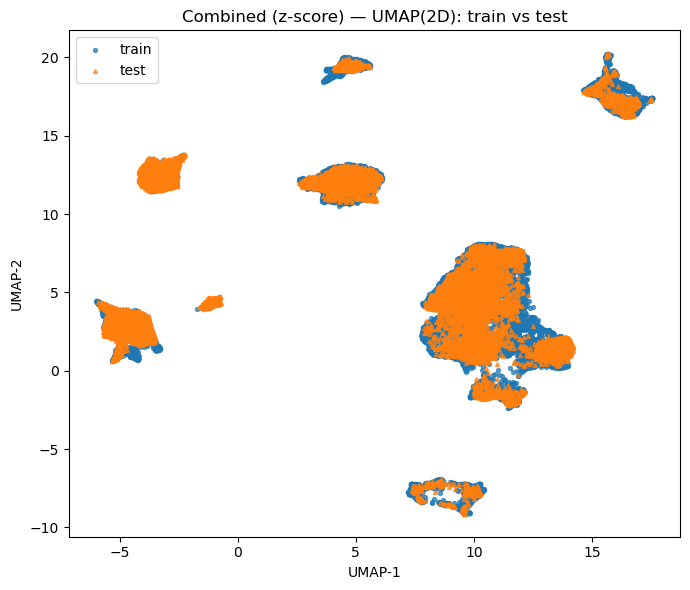

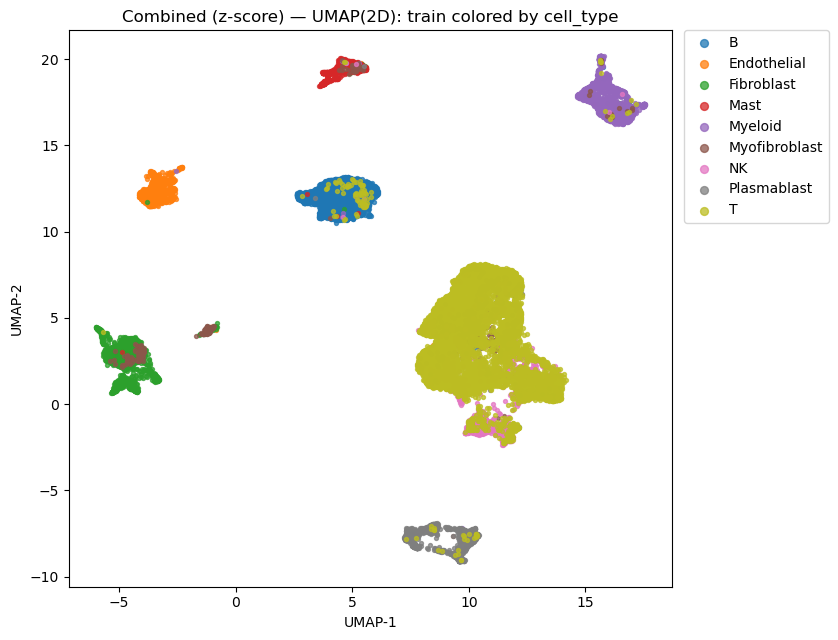

In [11]:
# file: scripts/plot_umap_2d_train_test_and_ct.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# UMAP (pip install umap-learn)
try:
    import umap
except Exception as e:
    raise RuntimeError("需要安裝 umap-learn：pip install umap-learn") from e


LABEL_COL = "cell_type"  # why: 上色/劃分
SET_COL = "set"          # why: train/test 分隔
RANDOM_STATE = 42
IN_DIR = "./outputs_features_csv/new_5/"

# UMAP hyperparams（可依需要調）
N_NEIGHBORS = 15         # why: 小群/局部結構
MIN_DIST    = 0.1
METRIC      = "euclidean"

def load_df(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty dataframe: {path}")
    return df

def get_masks(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    """why: 以 set 欄為準；不在就用 cell_type 有無視為 train/test。"""
    if SET_COL in df.columns:
        s = df[SET_COL].astype(str).str.lower()
        is_train = s.eq("train")
        is_test  = s.eq("test")
        if not is_train.any() and LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
    else:
        if LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
        else:
            is_train = pd.Series(True, index=df.index)
            is_test  = ~is_train
    return is_train, is_test

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """why: 僅數值欄；丟全 NaN/常數；不做標準化（需求指定）"""
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features after constant-column filtering.")
    # 填 NaN（UMAP 不能吃 NaN）
    Xdf = Xdf.fillna(Xdf.median(numeric_only=True))
    return Xdf

def run_umap(X: np.ndarray) -> np.ndarray:
    """why: 不標準化；直接以原尺度嵌入"""
    reducer = umap.UMAP(
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        n_components=2,
        metric=METRIC,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=False,
    )
    return reducer.fit_transform(X)

def scatter_train_vs_test(Z: np.ndarray, is_train: pd.Series, title: str):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z[is_train.values, 0], Z[is_train.values, 1], s=8, alpha=0.7, marker='o', label='train')
    if (~is_train).any():
        plt.scatter(Z[~is_train.values, 0], Z[~is_train.values, 1], s=8, alpha=0.7, marker='^', label='test')
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend()
    plt.tight_layout(); plt.show()

def scatter_train_by_ct(Z: np.ndarray, df: pd.DataFrame, is_train: pd.Series, title: str):
    if LABEL_COL not in df.columns:
        print("[Info] no 'cell_type' column; skip CT-colored plot.")
        return
    ct = df.loc[is_train, LABEL_COL].astype(str).fillna("NA")
    Zt = Z[is_train.values]
    # 排序：TARGET_ORDER 先，其他字母序
    if 'TARGET_ORDER' in globals() and isinstance(TARGET_ORDER, (list, tuple)):
        known = [c for c in TARGET_ORDER if c in ct.unique()]
        rest = sorted([c for c in ct.unique() if c not in known])
        order = known + rest
    else:
        order = sorted(ct.unique())

    plt.figure(figsize=(8.5, 6.5))
    for k in order:
        m = (ct == k).values
        if not np.any(m): 
            continue
        plt.scatter(Zt[m, 0], Zt[m, 1], s=8, alpha=0.75, label=str(k))
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout(); plt.show()

def main():
    for name, fname in FILES.items():
        path = os.path.join(IN_DIR, fname)
        df = load_df(path)
        is_train, is_test = get_masks(df)
        Xdf = numeric_feature_matrix(df)
        Z = run_umap(Xdf.to_numpy())

        # 1) train vs test
        scatter_train_vs_test(
            Z, is_train,
            title=f"{name} — UMAP(2D): train vs test"
        )
        # 2) train colored by cell_type
        scatter_train_by_ct(
            Z, df, is_train,
            title=f"{name} — UMAP(2D): train colored by cell_type"
        )

if __name__ == "__main__":
    main()
